In [2]:
from utils import*

In [3]:
# DS average
a_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv'
b_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv'
e_path = '../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv'
ab_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv'
abe_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBacEuk_recovered.csv'

xgroup2ds_a = csv2dict(a_path)
print(len(xgroup2ds_a))
xgroup2ds_b = csv2dict(b_path)
print(len(xgroup2ds_b))
xgroup2ds_e = csv2dict(e_path)
print(len(xgroup2ds_e))
xgroup2ds_ab = csv2dict(ab_path)
print(len(xgroup2ds_ab))
xgroup2ds_abe = csv2dict(abe_path)
print(len(xgroup2ds_abe))

2230
2230
2230
2230
2230


In [5]:
# new results

# NONE 1000 runs
df_folds_folditer = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_NONE.csv', index_col=0)
# preATP 1000 runs
# df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)

# Draw iterVSds

In [10]:
run2iter2ds = {}
for run in df_folds_folditer.columns:
    iter2ds = {}
    for x, i in df_folds_folditer[run].items():
        if x not in ['fold_independent', 'spontaneous']:
            if i not in iter2ds:
                iter2ds[i] = [x2ds[x]]
            else:
                iter2ds[i].append(x2ds[x])
    iter2ds_mean = {k:np.mean(v) for k,v in iter2ds.items()}
    run2iter2ds[run] = iter2ds_mean

iter2ds_mean_all = {}
for run, iter2ds in run2iter2ds.items():
    for i, ds in iter2ds.items():
        if i not in iter2ds_mean_all:
            iter2ds_mean_all[i] = [ds]
        else:
            iter2ds_mean_all[i].append(ds)
# take average over 1000 runs
iter2ds_mean_all_mean = {k:np.mean(v) for k,v in iter2ds_mean_all.items()}
iter2ds_mean_all_std = {k:np.std(v) for k,v in iter2ds_mean_all.items()}

folditer vs. average ds at iteration:
p_value = 1.027202768310673e-108, corr = -0.8589382445173462


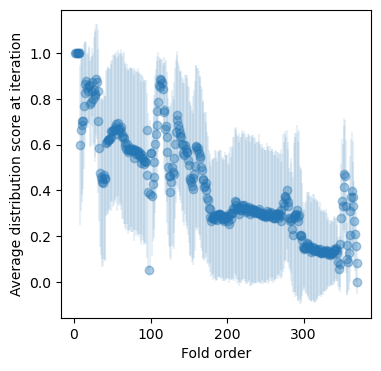

In [11]:
# std for error bar

y = list(iter2ds_mean_all_mean.values())  # average dist score
x = list(iter2ds_mean_all_mean.keys())  # iteration number
y_err = list(iter2ds_mean_all_std.values())  # variability 

# print Spearman correlation coeff.
corr, p = spearmanr(x, y)
print(f'folditer vs. average ds at iteration:')
print(f'p_value = {p}, corr = {corr}')

# Create a scatterplot with error bars
plt.figure(figsize=(4, 4))
plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.1, color='#2576B4')  # errorbar + data points
plt.scatter(x, y, marker='o', color='#2576B4', alpha = 0.3, zorder=2)  # data points (overlay to increase alpha)
plt.ylabel('Average distribution score at iteration')
plt.xlabel('Fold order')
# plt.savefig('iterVSds_range_std_error_2.png', dpi=300, bbox_inches = 'tight')
plt.show()

## do 95% CI instead
- within 1.96 STE of the mean)
- not std, so same as if you did STE

folditer vs. average ds at iteration:
p_value = 1.027202768310673e-108, corr = -0.8589382445173462


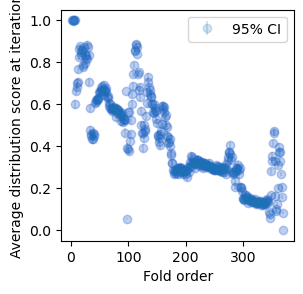

In [143]:
from scipy.stats import t, spearmanr

y = list(iter2ds_mean_all_mean.values())  # average dist score
x = list(iter2ds_mean_all_mean.keys())  # iteration number
std_dev = list(iter2ds_mean_all_std.values())  # standard deviation
n = 1000  # Example: replace with actual sample sizes

# Calculate the 95% confidence interval
sem = np.array(std_dev) / np.sqrt(n)
t_critical = t.ppf(0.975, df=n-1)  # Two-tailed, 95% CI
y_err = t_critical * sem

# Print Spearman correlation coefficient
corr, p = spearmanr(x, y)
print(f'folditer vs. average ds at iteration:')
print(f'p_value = {p}, corr = {corr}')

# Create a scatterplot with error bars
plt.figure(figsize=(3, 3))
plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.2, label='95% CI')
plt.scatter(x, y, marker='o', color='b', alpha=0.1, zorder=2)
plt.ylabel('Average distribution score at iteration')
plt.xlabel('Fold order')
plt.legend()
plt.show()

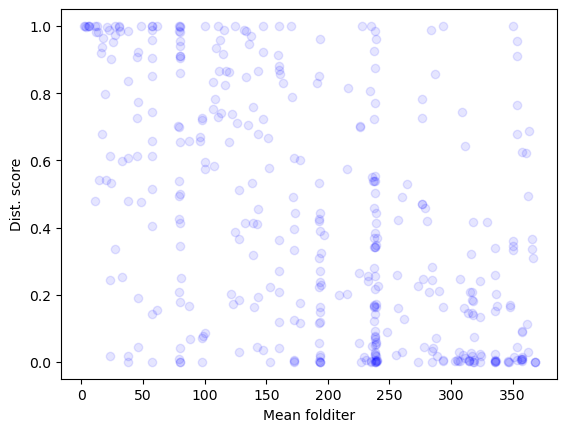

In [59]:
x2foMean = {}
x2foStd = {}
for x in df_folds_folditer.index:
    if x not in ['fold_independent', 'spontaneous']:
        x2foMean[x] = np.mean(df_folds_folditer.loc[x])
        x2foStd[x] = np.std(df_folds_folditer.loc[x])

scatter(x2foMean, x2ds, 'Mean folditer', 'Dist. score')

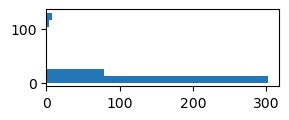

In [200]:
data1 = list(x2foStd.values())
plt.figure(figsize=(3, 1))
plt.hist(data1, bins=10, color='#2576B4', edgecolor=None, orientation='horizontal')
# plt.ylabel('Std.')
# plt.xlabel('Lineage Count')

# plt.yscale('log', nonpositive='clip')
# plt.savefig('inset.svg', dpi=300, bbox_inches = 'tight')

plt.show()

## adjust for oscillation

In [149]:
lengths = set()
for run in df_folds_folditer.columns:
    lengths.add(max(df_folds_folditer[run]))
lengths

{366, 367, 368, 369, 370}

folditer vs. average ds at iteration:
p_value = 1.7163196688057583e-90, corr = -0.8212795683660353


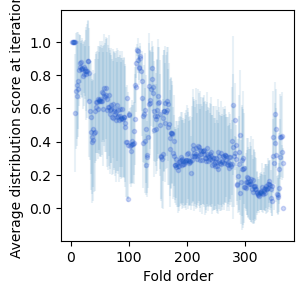

In [151]:
run2iter2ds = {}

for run in df_folds_folditer.columns:
    iter2ds = {}
    for x, i in df_folds_folditer[run].items():
        if x not in ['fold_independent', 'spontaneous']:
            if i not in iter2ds:
                iter2ds[i] = [x2ds[x]]
            else:
                iter2ds[i].append(x2ds[x])
    iter2ds_mean = {k:np.mean(v) for k,v in iter2ds.items()}
    
    if max(df_folds_folditer[run]) == 366:  # check length
        run2iter2ds[run] = iter2ds_mean


iter2ds_mean_all = {}
for run, iter2ds in run2iter2ds.items():
    for i, ds in iter2ds.items():
        if i not in iter2ds_mean_all:
            iter2ds_mean_all[i] = [ds]
        else:
            iter2ds_mean_all[i].append(ds)
            
# take average over 1000 runs
iter2ds_mean_all_mean = {k:np.mean(v) for k,v in iter2ds_mean_all.items()}
iter2ds_mean_all_std = {k:np.std(v) for k,v in iter2ds_mean_all.items()}


# plot
y = list(iter2ds_mean_all_mean.values())  # average dist score
x = list(iter2ds_mean_all_mean.keys())  # iteration number
y_err = list(iter2ds_mean_all_std.values())  # variability 

# print Spearman correlation coeff.
corr, p = spearmanr(x, y)
print(f'folditer vs. average ds at iteration:')
print(f'p_value = {p}, corr = {corr}')

# Create a scatterplot with error bars
plt.figure(figsize=(4, 4))
plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.1)  # errorbar + data points
plt.scatter(x, y, marker='o', color='b', alpha = 0.3, zorder=2)  # data points (overlay to increase alpha)
plt.ylabel('Average distribution score at iteration')
plt.xlabel('Fold order')

plt.show()